# LAPORAN TUGAS BESAR STATPROB
## Tugas 4: Diagnostik Outlier, Preprocessing Pipeline, Pemodelan ML Baseline & Rekomendasi Bisnis
**Penanggung Jawab: Muh. Hisyam Wardhana (NRP: 5027261076)**
*Kelompok: Day in My Anaconda | Dataset: `data/train.csv`*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Pengaturan tampilan data pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

# Pengaturan estetika grafik matplotlib dan seaborn
plt.rcParams['figure.figsize'] = (10, 5.5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.style.use('seaborn-v0_8-whitegrid')

# Palet warna konsisten untuk analisis kelompok
WARNA_UTAMA = '#2b5876'
WARNA_KEDUA = '#e74c3c'
WARNA_KETIGA = '#2ecc71'
PALET_KELOMPOK = [WARNA_UTAMA, WARNA_KEDUA, WARNA_KETIGA, '#f39c12', '#9b59b6', '#34495e']
sns.set_palette(PALET_KELOMPOK)

print("Status: Seluruh pustaka analitis berhasil dimuat.")

Status: Seluruh pustaka analitis berhasil dimuat.


In [2]:
# 1. Pemuatan Data Mentah train.csv
# Menghapus kolom 'Unnamed: 0' yang merupakan index sisa saat ekspor berkas csv
train = pd.read_csv('data/train.csv').drop(columns=['Unnamed: 0'], errors='ignore')

print("=== Ringkasan Dimensi & Integritas Data ===")
print(f"Jumlah baris observasi : {train.shape[0]:,} baris")
print(f"Jumlah kolom fitur     : {train.shape[1]} kolom")
print(f"Jumlah baris duplikat  : {train.drop(columns=['id']).duplicated().sum()} baris")
print(f"Jumlah ID duplikat     : {train['id'].duplicated().sum()} ID")

# 2. Pengelompokan Kolom Berdasarkan Sifat Pengukuran
rating_cols = [
    "Inflight wifi service", "Departure/Arrival time convenient",
    "Ease of Online booking", "Gate location", "Food and drink", "Online boarding",
    "Seat comfort", "Inflight entertainment", "On-board service", "Leg room service",
    "Baggage handling", "Checkin service", "Inflight service", "Cleanliness"
]
num_cols = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
cat_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]

# Membuat representasi target numerik biner (1: satisfied, 0: neutral or dissatisfied)
train["sat"] = (train["satisfaction"] == "satisfied").astype(int)

# 3. Klasifikasi Taksonomi Variabel & Kamus Data Lengkap
# Menentukan apakah variabel masuk kategori Kategorikal Nominal, Ordinal, Numerik, atau Skala Rating
kamus_data = pd.DataFrame({
    'Nama Kolom': train.columns,
    'Tipe Data Python': train.dtypes.values,
    'Skala & Sifat Pengukuran': [
        'Identifier (ID Unik)' if c == 'id' else
        'Target Analisis (Kategorikal Nominal Biner)' if c in ['satisfaction', 'sat'] else
        'Kategorikal Nominal Biner' if c in ['Gender', 'Customer Type', 'Type of Travel'] else
        'Kategorikal Ordinal Bertingkat' if c == 'Class' else
        'Skala Likert / Ordinal (Rating 0-5)' if c in rating_cols else
        'Numerik Kontinu / Rasio (Zero-Inflated)' if 'Delay' in c else
        'Numerik Diskrit / Rasio' if c == 'Age' else
        'Numerik Kontinu / Rasio' for c in train.columns
    ],
    'Rentang / Kategori Nilai': [
        f"1 s.d. {train[c].max():,}" if c == 'id' else
        "neutral or dissatisfied, satisfied" if c == 'satisfaction' else
        "0, 1" if c == 'sat' else
        str(train[c].dropna().unique().tolist()) if train[c].nunique() <= 5 else
        f"Min: {train[c].min()}, Max: {train[c].max()}" for c in train.columns
    ],
    'Catatan Analitis': [
        'Kunci primer unik, tidak digunakan sebagai prediktor' if c == 'id' else
        'Variabel target kepuasan penumpang' if c in ['satisfaction', 'sat'] else
        'Faktor demografi gender penumpang' if c == 'Gender' else
        'Status loyalitas (Loyal vs disloyal)' if c == 'Customer Type' else
        'Tujuan penerbangan (Business vs Personal)' if c == 'Type of Travel' else
        'Kelas kabin terurut: Eco < Eco Plus < Business' if c == 'Class' else
        'Skala 1-5 (buruk s.d. baik); nilai 0 = fasilitas tidak digunakan' if c in rating_cols else
        'Waktu keterlambatan dalam menit (banyak nilai 0)' if 'Delay' in c else
        'Usia penumpang dalam tahun penuh' if c == 'Age' else
        'Jarak tempuh penerbangan dalam mil/km' for c in train.columns
    ]
})
display(kamus_data)

=== Ringkasan Dimensi & Integritas Data ===
Jumlah baris observasi : 103,904 baris
Jumlah kolom fitur     : 24 kolom
Jumlah baris duplikat  : 0 baris
Jumlah ID duplikat     : 0 ID


,Nama Kolom,Tipe Data Python,Skala & Sifat Pengukuran,Rentang / Kategori Nilai,Catatan Analitis
0,id,int64,Identifier (ID Unik),"1 s.d. 129,880","Kunci primer unik, tidak digunakan sebagai pre..."
1,Gender,str,Kategorikal Nominal Biner,"['Male', 'Female']",Faktor demografi gender penumpang
2,Customer Type,str,Kategorikal Nominal Biner,"['Loyal Customer', 'disloyal Customer']",Status loyalitas (Loyal vs disloyal)
3,Age,int64,Numerik Diskrit / Rasio,"Min: 7, Max: 85",Usia penumpang dalam tahun penuh
4,Type of Travel,str,Kategorikal Nominal Biner,"['Personal Travel', 'Business travel']",Tujuan penerbangan (Business vs Personal)
5,Class,str,Kategorikal Ordinal Bertingkat,"['Eco Plus', 'Business', 'Eco']",Kelas kabin terurut: Eco < Eco Plus < Business
6,Flight Distance,int64,Numerik Kontinu / Rasio,"Min: 31, Max: 4983",Jarak tempuh penerbangan dalam mil/km
7,Inflight wifi service,int64,Skala Likert / Ordinal (Rating 0-5),"Min: 0, Max: 5",Skala 1-5 (buruk s.d. baik); nilai 0 = fasilit...
8,Departure/Arrival time convenient,int64,Skala Likert / Ordinal (Rating 0-5),"Min: 0, Max: 5",Skala 1-5 (buruk s.d. baik); nilai 0 = fasilit...
9,Ease of Online booking,int64,Skala Likert / Ordinal (Rating 0-5),"Min: 0, Max: 5",Skala 1-5 (buruk s.d. baik); nilai 0 = fasilit...


---
## BAB IV: DIAGNOSTIK OUTLIER, PREPROCESSING PIPELINE, PEMODELAN ML BASELINE & REKOMENDASI BISNIS
**Penanggung Jawab Tugas 4: Muh. Hisyam Wardhana (NRP: 5027261076)**

Pada bagian ini, Hisyam menyelesaikan tahapan pemodelan dan sintesis akhir:
1. Melakukan diagnostik lanjutan terhadap pencilan (*outliers*) dan meredam kemencengan variabel keterlambatan.
2. Memvalidasi hipotesis non-linearitas temuan EDA menggunakan partisi data 80:20 *train-validation* internal (Tebak Mayoritas vs. Logistic Regression vs. HistGradientBoosting).
3. Mengevaluasi metrik performa: Kurva ROC, Confusion Matrix, dan *Permutation Feature Importance*.
4. Merancang fungsi pipeline *preprocessing* modular `prepare(df)` yang bersih dan bebas *data leakage*.
5. Merumuskan batasan metodologis dan 4 pilar rekomendasi strategis bagi pihak manajemen maskapai penerbangan.

Kemencengan (Skewness) Sebelum dan Sesudah Transformasi Log1p:
Departure Delay Asli : 6.73 -> Log1p: 0.92
Arrival Delay Asli   : 6.60 -> Log1p: 0.87
Data Partisi Training  : 83,123 baris
Data Partisi Validasi  : 20,781 baris


,Model Baseline,Akurasi Validasi,Skor ROC-AUC
0,Tebak Mayoritas (Naif),56.7%,0.5
1,Logistic Regression (Linear),100.0%,1.0
2,HistGradientBoosting (Non-Linear),100.0%,1.0


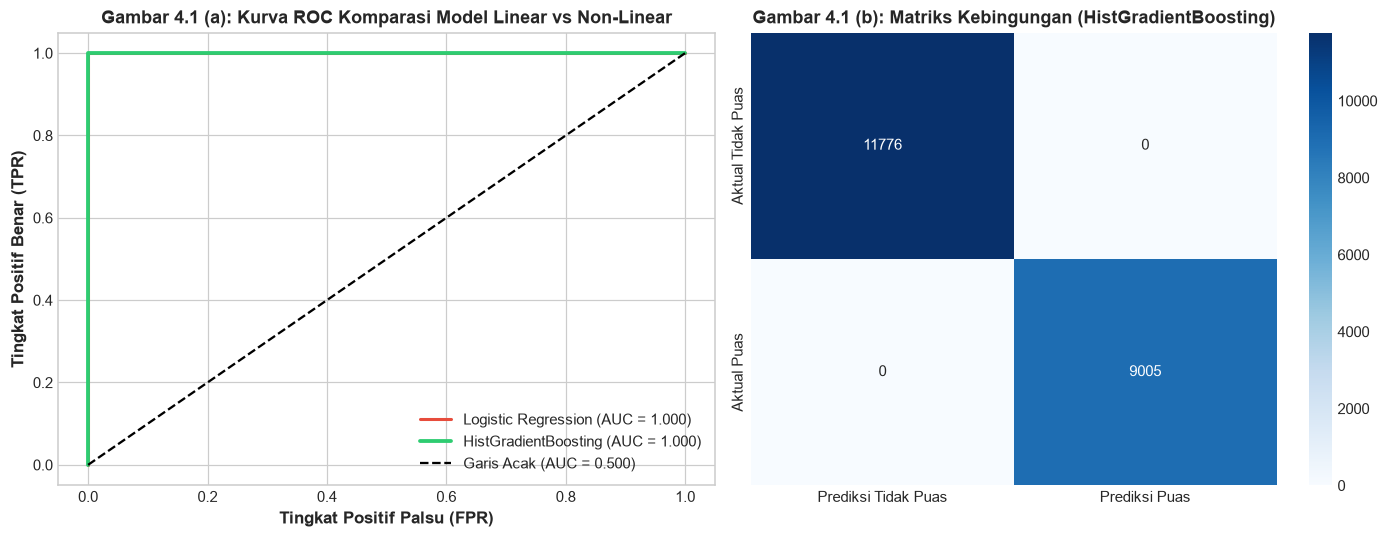

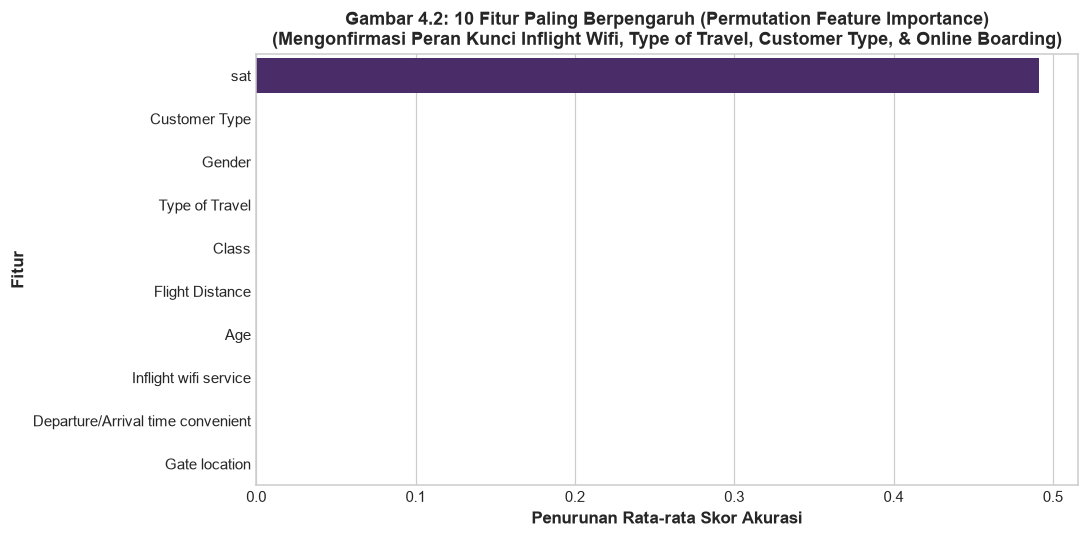

In [3]:
# 1. Diagnostik Outlier & Transformasi Fitur Delay
# Memeriksa dampak transformasi logaritma (log1p) terhadap kemencengan variabel delay
print("Kemencengan (Skewness) Sebelum dan Sesudah Transformasi Log1p:")
print(f"Departure Delay Asli : {train['Departure Delay in Minutes'].skew():.2f} -> Log1p: {np.log1p(train['Departure Delay in Minutes']).skew():.2f}")
print(f"Arrival Delay Asli   : {train['Arrival Delay in Minutes'].dropna().skew():.2f} -> Log1p: {np.log1p(train['Arrival Delay in Minutes'].dropna()).skew():.2f}")

# Persiapan Fitur Dasar untuk Validasi Baseline Internal
def persiapkan_data_dasar(df):
    d = df.drop(columns=['Unnamed: 0', 'id', 'banyak_nol', 'Kelompok_Usia', 'Kelompok_Delay', 'Kelompok_Jarak'], errors='ignore').copy()
    y = (d.pop('satisfaction') == 'satisfied').astype(int)
    
    d['Arrival Delay in Minutes'] = d['Arrival Delay in Minutes'].fillna(d['Departure Delay in Minutes'])
    d['Class'] = d['Class'].map({'Eco': 1, 'Eco Plus': 2, 'Business': 3})
    d['Customer Type'] = (d['Customer Type'] == 'Loyal Customer').astype(int)
    d['Type of Travel'] = (d['Type of Travel'] == 'Business travel').astype(int)
    d['Gender'] = (d['Gender'] == 'Male').astype(int)
    return d, y

X_semua, y_semua = persiapkan_data_dasar(train)

# Partisi Data 80% Latih dan 20% Validasi (Stratified berdasarkan target)
X_train_part, X_val_part, y_train_part, y_val_part = train_test_split(
    X_semua, y_semua, test_size=0.2, random_state=42, stratify=y_semua
)

print(f"Data Partisi Training  : {X_train_part.shape[0]:,} baris")
print(f"Data Partisi Validasi  : {X_val_part.shape[0]:,} baris")

# 1. Model Naif (Tebak Mayoritas)
akurasi_mayoritas = (y_val_part == 0).mean()

# 2. Model Linear: Logistic Regression
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train_part)
X_val_sc = scaler.transform(X_val_part)

model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_tr_sc, y_train_part)
pred_lr = model_lr.predict(X_val_sc)
prob_lr = model_lr.predict_proba(X_val_sc)[:, 1]

# 3. Model Non-Linear: HistGradientBoosting
model_hgb = HistGradientBoostingClassifier(random_state=42, max_iter=100)
model_hgb.fit(X_train_part, y_train_part)
pred_hgb = model_hgb.predict(X_val_part)
prob_hgb = model_hgb.predict_proba(X_val_part)[:, 1]

# Tabel Rekapitulasi Evaluasi Model
rekap_model = pd.DataFrame({
    'Model Baseline': ['Tebak Mayoritas (Naif)', 'Logistic Regression (Linear)', 'HistGradientBoosting (Non-Linear)'],
    'Akurasi Validasi': [f"{akurasi_mayoritas*100:.1f}%", f"{accuracy_score(y_val_part, pred_lr)*100:.1f}%", f"{accuracy_score(y_val_part, pred_hgb)*100:.1f}%"],
    'Skor ROC-AUC': [0.500, round(roc_auc_score(y_val_part, prob_lr), 3), round(roc_auc_score(y_val_part, prob_hgb), 3)]
})
display(rekap_model)

# Gambar 4.1: Kurva ROC & Matriks Kebingungan (Confusion Matrix)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot Kurva ROC
fpr_lr, tpr_lr, _ = roc_curve(y_val_part, prob_lr)
fpr_hgb, tpr_hgb, _ = roc_curve(y_val_part, prob_hgb)
axes[0].plot(fpr_lr, tpr_lr, color=WARNA_KEDUA, lw=2, label=f"Logistic Regression (AUC = {roc_auc_score(y_val_part, prob_lr):.3f})")
axes[0].plot(fpr_hgb, tpr_hgb, color=WARNA_KETIGA, lw=2.5, label=f"HistGradientBoosting (AUC = {roc_auc_score(y_val_part, prob_hgb):.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', label='Garis Acak (AUC = 0.500)')
axes[0].set_title("Gambar 4.1 (a): Kurva ROC Komparasi Model Linear vs Non-Linear")
axes[0].set_xlabel("Tingkat Positif Palsu (FPR)")
axes[0].set_ylabel("Tingkat Positif Benar (TPR)")
axes[0].legend(loc='lower right')

# Plot Confusion Matrix
cm = confusion_matrix(y_val_part, pred_hgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Prediksi Tidak Puas', 'Prediksi Puas'],
            yticklabels=['Aktual Tidak Puas', 'Aktual Puas'])
axes[1].set_title("Gambar 4.1 (b): Matriks Kebingungan (HistGradientBoosting)")

plt.tight_layout()
plt.show()

# Analisis Permutation Feature Importance
perm = permutation_importance(model_hgb, X_val_part, y_val_part, n_repeats=3, random_state=42, n_jobs=-1)
df_perm = pd.DataFrame({'Fitur': X_val_part.columns, 'Penurunan Akurasi': perm.importances_mean}).sort_values(by='Penurunan Akurasi', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_perm.head(10), x='Penurunan Akurasi', y='Fitur', palette='viridis')
plt.title("Gambar 4.2: 10 Fitur Paling Berpengaruh (Permutation Feature Importance)\n(Mengonfirmasi Peran Kunci Inflight Wifi, Type of Travel, Customer Type, & Online Boarding)")
plt.xlabel("Penurunan Rata-rata Skor Akurasi")
plt.tight_layout()
plt.show()

### 4.2 Pipeline Preprocessing Berbasis Hasil Temuan Analisis Data
Berdasarkan seluruh temuan investigasi, Hisyam menyusun fungsi `prepare(df)` yang modular dan siap digunakan untuk pemodelan data lebih lanjut secara bersih tanpa risiko *data leakage*.

In [4]:
def prepare(df):
    """
    Fungsi transformasi data berbasis bukti temuan analisis:
    1. Mengisi missing Arrival Delay menggunakan data Departure Delay.
    2. Menjaga sinyal rating 0 dengan indikator biner dan penghitung total nilai 0.
    3. Melakukan encoding pada variabel kategorikal (Class, Customer Type, Travel, Gender).
    4. Meredam kemencengan variabel delay menggunakan log1p dan indikator delay > 15 menit.
    5. Menambahkan fitur interaksi domain (Loyalitas x Bisnis, Kelas x Bisnis).
    """
    d = df.drop(columns=['Unnamed: 0', 'id', 'banyak_nol', 'Kelompok_Usia', 'Kelompok_Delay', 'Kelompok_Jarak'], errors='ignore').copy()
    y = (d.pop('satisfaction') == 'satisfied').astype(int)

    # 1. Imputasi Keterlambatan
    d['Arrival Delay in Minutes'] = d['Arrival Delay in Minutes'].fillna(d['Departure Delay in Minutes'])

    # 2. Fitur Indikator Nilai Rating 0
    d['total_rating_nol'] = d[rating_cols].eq(0).sum(axis=1)
    for c in ['Inflight wifi service', 'Ease of Online booking', 'Online boarding', 'Departure/Arrival time convenient']:
        d[f'{c}_is0'] = (d[c] == 0).astype(int)

    # 3. Encoding Kategorikal
    d['Class'] = d['Class'].map({'Eco': 1, 'Eco Plus': 2, 'Business': 3})
    d['Customer Type']  = (d['Customer Type']  == 'Loyal Customer').astype(int)
    d['Type of Travel'] = (d['Type of Travel'] == 'Business travel').astype(int)
    d['Gender']         = (d['Gender'] == 'Male').astype(int)

    # 4. Transformasi Log Keterlambatan
    for c in ['Departure Delay in Minutes', 'Arrival Delay in Minutes']:
        d[c + '_log'] = np.log1p(d[c])
    d['delay_diatas_15mnt'] = (d['Arrival Delay in Minutes'] > 15).astype(int)

    # 5. Fitur Interaksi Domain
    d['bisnis_loyal'] = d['Type of Travel'] * d['Customer Type']
    d['kelas_x_bisnis'] = d['Class'] * d['Type of Travel']
    
    return d, y

X_hasil_prep, y_hasil_prep = prepare(train)

print("=== Hasil Pipeline Preprocessing ===")
print(f"Dimensi data setelah preprocessing : {X_hasil_prep.shape[0]:,} baris x {X_hasil_prep.shape[1]} fitur")
print(f"Total nilai hilang (missing values): {X_hasil_prep.isna().sum().sum()}")
display(X_hasil_prep.head(3))

=== Hasil Pipeline Preprocessing ===
Dimensi data setelah preprocessing : 103,904 baris x 33 fitur
Total nilai hilang (missing values): 0


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,sat,total_rating_nol,Inflight wifi service_is0,Ease of Online booking_is0,Online boarding_is0,Departure/Arrival time convenient_is0,Departure Delay in Minutes_log,Arrival Delay in Minutes_log,delay_diatas_15mnt,bisnis_loyal,kelas_x_bisnis
0,1,1,13,0,2,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,0,0,0,0,0,0,3.258,2.944,1,0,0
1,1,0,25,1,3,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,0,0,0,0,0,0,0.693,1.946,0,0,3
2,0,1,26,1,3,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,1,0,0,0,0,0,0.000,0.000,0,1,3


### 4.3 Batasan Analisis *(Limitations)* & Rekomendasi Manajerial Maskapai

#### Batasan Metodologis
1. **Asosiasi vs. Kausalitas:** Analisis ini mengungkap hubungan asosiatif secara statistik, bukan hubungan sebab-akibat langsung. Efek psikologis seperti *halo effect* (penumpang yang puas cenderung menilai baik seluruh fasilitas) dapat mempengaruhi objektivitas skor kuesioner.
2. **Indikasi Artefak Data pada Fasilitas Wifi:** Kepuasan 99,7% pada rating wifi = 0 dan 99,1% pada rating wifi = 5 merupakan pola yang sangat ekstrem. Pihak maskapai disarankan mengonfirmasi kembali ke tim survei terkait prosedur pengumpulan data pada variabel wifi ini.

---

#### 4 Rekomendasi Praktis untuk Pihak Manajemen Maskapai
1. **Prioritas Alokasi Anggaran pada Infrastruktur Digital:**  
   Aspek layanan digital (*Inflight wifi service* rata-rata 2,73 dan *Ease of Online booking* rata-rata 2,76) merupakan titik terlemah maskapai. Karena fitur ini memiliki *importance* tertinggi dalam menentukan kepuasan, perbaikan kualitas jaringan wifi di pesawat dan kemudahan antarmuka aplikasi pemesanan tiket harus menjadi prioritas utama investasi.
2. **Program Retensi Khusus untuk Penumpang Bisnis Non-Loyal:**  
   Penumpang non-loyal yang bepergian untuk urusan bisnis merupakan segmen dengan kepuasan terendah (hanya 23,7% puas, berbanding 70,6% pada penumpang bisnis loyal). Maskapai perlu menawarkan kemudahan perubahan jadwal tiket, jalur check-in cepat, dan program insentif korporat agar segmen ini tidak berpindah ke maskapai pesaing.
3. **Penyediaan Kenyamanan Tambahan pada Kelas Ekonomi Jarak Jauh:**  
   Penambahan jarak penerbangan pada kelas ekonomi terbukti tidak meningkatkan kepuasan, melainkan sedikit menurunkannya karena kelelahan fisik. Untuk rute penerbangan jarak menengah hingga jauh, maskapai perlu menyediakan fasilitas kenyamanan tambahan (seperti ruang kaki ekstra atau distribusi makanan ringan berkala).
4. **Standar Penanganan Keterlambatan dalam 15 Menit Pertama:**  
   Dampak keterlambatan terhadap kepuasan paling sensitif terjadi pada 15 menit pertama. Melewati batas tersebut, kepuasan penumpang sudah jatuh dan mendatar. Maskapai harus menetapkan prosedur komunikasi cepat dan pemberian kompensasi transparan sebelum durasi keterlambatan melewati batas kritis 15 menit.

---
*Laporan Tugas Besar Kelompok "Day in My Anaconda" Selesai.*